# NeuralNav — Retrieval (sentence-transformers + FAISS) and NER (spaCy)

Run on Kaggle (GPU optional here — embedding a small KB is fast even on CPU, but leave GPU on since it's free with your quota). Internet must be ON since this pulls `kb.json`/`intents_real.csv` from the Hugging Face Hub.

**Loads directly from the Hub** — no manual Kaggle dataset upload needed. `kb.json` and `intents_real.csv` are pulled from the same HF repo that `01_intent_classification.ipynb` pushes to at the end of its run (`HF_REPO_ID`, default `unixio/neuralnav-intent-models`), with an inline fallback if the repo/files aren't found yet.

**Evaluation, not just a sanity check**: this notebook evaluates retrieval quality with hit-rate@k using `intents_real.csv` (the same low-data, 25-examples/class set from notebook 01) as a labeled query set — for each query we check whether the top-k retrieved KB entries include one whose `intent` matches the query's true intent. That mirrors the low-data framing from notebook 01: with a small, sparse KB (3 entries/intent), retrieval quality is exactly the kind of thing that's expected to degrade — measuring it (rather than asserting it) is the point.

Outputs: `kb_embeddings.npy`, `kb_index.faiss`, and `figures/` (hit-rate charts, score distributions, KB embedding scatter, NER entity-count chart) — pushed back to the **same HF repo** at the end of this notebook, alongside being saved locally to `/kaggle/working/`. The FastAPI backend (`ml/retrieval.py`) can load either the local files or pull straight from that HF repo.

In [1]:
!pip install -q sentence-transformers faiss-cpu spacy pandas scikit-learn matplotlib seaborn huggingface_hub
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

In [2]:
import os, json

HF_REPO_ID = "unixio/neuralnav-intent-models"  # must match notebook 01's HF_REPO_ID

hf_token = os.environ.get("HF_TOKEN")
if not hf_token:
    try:
        from kaggle_secrets import UserSecretsClient
        hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        hf_token = None

KB_PATH = None
if hf_token:
    try:
        from huggingface_hub import hf_hub_download
        KB_PATH = hf_hub_download(repo_id=HF_REPO_ID, filename="kb.json", token=hf_token)
        print(f"Loaded kb.json from HF Hub: {HF_REPO_ID}")
    except Exception as e:
        print(f"Could not fetch kb.json from HF Hub ({e}); falling back.")

if KB_PATH is None:
    KB_PATH = "/kaggle/input/neuralnav-kb/kb.json"
if not os.path.exists(KB_PATH):
    KB_PATH = "/kaggle/working/kb.json"
if not os.path.exists(KB_PATH):
    print("NOTE: kb.json not found via HF Hub or Kaggle dataset — using a tiny inline "
          "fallback. Set HF_TOKEN (Kaggle secret) so this notebook can pull the real "
          "kb.json pushed by notebook 01.")
    sample_kb = [
        {"id": "kb_power_1", "intent": "power_issue", "question": "Device won't turn on",
         "answer": "Hold the power button for 10 seconds to force a restart."}
    ]
    json.dump(sample_kb, open(KB_PATH, "w"))

kb = json.load(open(KB_PATH))
len(kb)

kb.json: 0.00B [00:00, ?B/s]

Loaded kb.json from HF Hub: unixio/neuralnav-intent-models


81

In [3]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

EMBED_MODEL = "all-MiniLM-L6-v2"
model = SentenceTransformer(EMBED_MODEL)

texts = [f"{item['question']} {item['answer']}" for item in kb]
embeddings = model.encode(texts, normalize_embeddings=True)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(np.asarray(embeddings, dtype=np.float32))

np.save("/kaggle/working/kb_embeddings.npy", embeddings)
faiss.write_index(index, "/kaggle/working/kb_index.faiss")
print("Saved embeddings + FAISS index.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Saved embeddings + FAISS index.


In [4]:
# Sanity check the retrieval quality before downloading
query = "my wifi disconnects randomly"
q_emb = model.encode([query], normalize_embeddings=True)
scores, idxs = index.search(np.asarray(q_emb, dtype=np.float32), 3)
for score, idx in zip(scores[0], idxs[0]):
    print(round(float(score), 3), kb[idx]["question"], "->", kb[idx]["answer"])

0.192 there is a trouble setting another delivery address up -> I'm sorry to hear that you're experiencing trouble setting up another delivery address. I understand the importance of having a smooth and seamless process for entering your address details. To better assist you, could you please provide more specific information about the issues you are facing? Are you encountering any error messages or is the system not accepting the address you're inputting? By understanding the exact nature of the problem, I'll be able to provide you with the most accurate guidance and help you resolve the issue effectively.
0.184 i cant switch to the premium account -> I'm sorry to hear that you're having trouble switching to the premium account. Let's work together to resolve this issue and get you upgraded to the premium experience you deserve.

1. Troubleshoot: First, let's try to identify the specific issue you're facing. Are you receiving any error messages or encountering any difficulties during

## Retrieval evaluation: hit-rate@k on held-out queries

Loads `intents_real.csv` (the labeled 25-examples/class set from notebook
01) as a held-out query set. For each query, retrieve the top-k KB entries
and check whether any of them share the query's true intent — this is the
hit-rate@k metric for the retrieval step, analogous to accuracy for the
classifiers in notebook 01.

In [5]:
import pandas as pd

EVAL_PATH = None
if hf_token:
    try:
        from huggingface_hub import hf_hub_download
        EVAL_PATH = hf_hub_download(repo_id=HF_REPO_ID, filename="intents_real.csv", token=hf_token)
        print(f"Loaded intents_real.csv from HF Hub: {HF_REPO_ID}")
    except Exception as e:
        print(f"Could not fetch intents_real.csv from HF Hub ({e}); falling back.")

if EVAL_PATH is None:
    EVAL_PATH = "/kaggle/input/neuralnav-intents-real/intents_real.csv"
if not os.path.exists(EVAL_PATH):
    EVAL_PATH = "/kaggle/working/intents_real.csv"
if not os.path.exists(EVAL_PATH):
    print("NOTE: intents_real.csv not found via HF Hub or Kaggle dataset — falling back "
          "to evaluating on the KB's own questions, which trivially scores ~100%. Set "
          "HF_TOKEN (Kaggle secret) for a real evaluation.")
    eval_df = pd.DataFrame([{"text": item["question"], "intent": item["intent"]} for item in kb])
else:
    eval_df = pd.read_csv(EVAL_PATH)[["text", "intent"]].dropna()

print(eval_df.shape)
eval_df.head()

intents_real.csv: 0.00B [00:00, ?B/s]

Loaded intents_real.csv from HF Hub: unixio/neuralnav-intent-models
(675, 2)


,text,intent
0,I cannot afford purchase {{Order Number}},cancel_order
1,"I have bought some item, I have to cancel orde...",cancel_order
2,"I do not want this item, cancel order {{Order ...",cancel_order
3,I need assistance with canceling purchase {{Or...,cancel_order
4,were can i cancel purchase {{Order Number}},cancel_order


In [6]:
K_VALUES = [1, 3, 5]
MAX_K = max(K_VALUES)

kb_intents = np.array([item["intent"] for item in kb])
query_embeddings = model.encode(eval_df["text"].tolist(), normalize_embeddings=True)
scores_all, idxs_all = index.search(np.asarray(query_embeddings, dtype=np.float32), MAX_K)

records = []
for row, scores, idxs in zip(eval_df.itertuples(), scores_all, idxs_all):
    retrieved_intents = kb_intents[idxs]
    record = {"text": row.text, "true_intent": row.intent, "top1_score": float(scores[0])}
    for k in K_VALUES:
        record[f"hit@{k}"] = bool(row.intent in retrieved_intents[:k])
    records.append(record)

eval_results = pd.DataFrame(records)
hit_rates = {f"hit@{k}": eval_results[f"hit@{k}"].mean() for k in K_VALUES}
print("Overall hit-rate@k:", hit_rates)

Overall hit-rate@k: {'hit@1': np.float64(0.8651851851851852), 'hit@3': np.float64(0.9629629629629629), 'hit@5': np.float64(0.9822222222222222)}


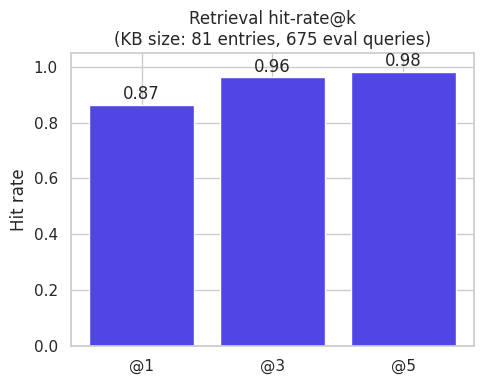

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = "/kaggle/working/figures"
os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")

# Overall hit-rate@k
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([f"@{k}" for k in K_VALUES], [hit_rates[f"hit@{k}"] for k in K_VALUES], color="#4f46e5")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Hit rate")
ax.set_title(f"Retrieval hit-rate@k\n(KB size: {len(kb)} entries, {eval_df.shape[0]} eval queries)")
for i, k in enumerate(K_VALUES):
    ax.text(i, hit_rates[f"hit@{k}"] + 0.02, f'{hit_rates[f"hit@{k}"]:.2f}', ha="center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/retrieval_hitrate_overall.png", dpi=150, bbox_inches="tight")
plt.show()

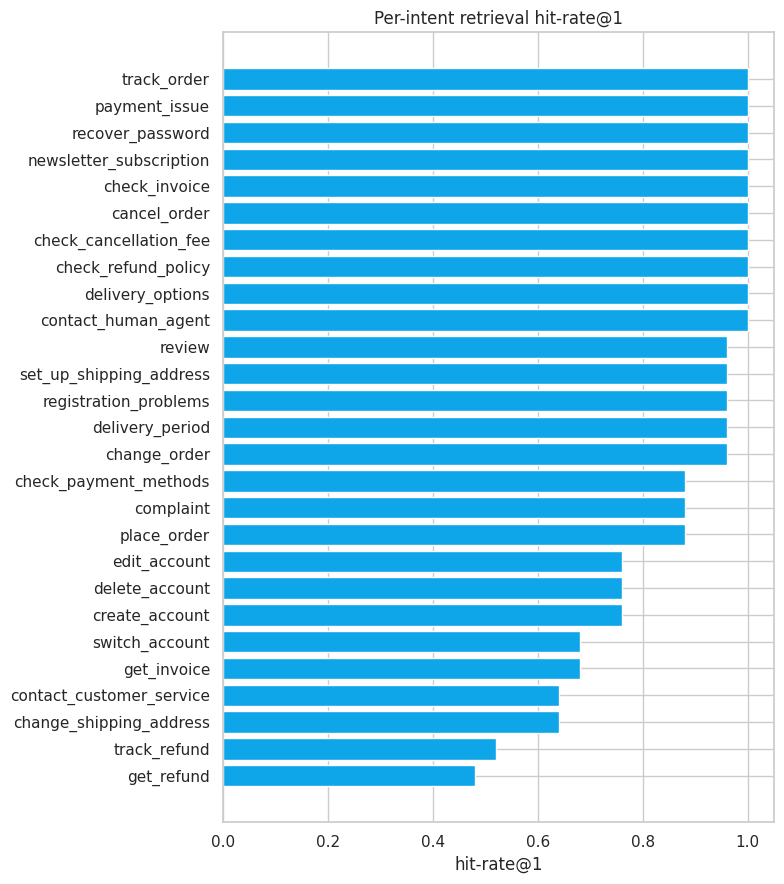

In [8]:
# Per-intent hit-rate@1 — shows which intents the sparse KB serves worst
per_intent = eval_results.groupby("true_intent")["hit@1"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(per_intent.index, per_intent.values, color="#0ea5e9")
ax.set_xlim(0, 1.05)
ax.set_xlabel("hit-rate@1")
ax.set_title("Per-intent retrieval hit-rate@1")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/retrieval_hitrate_per_intent.png", dpi=150, bbox_inches="tight")
plt.show()

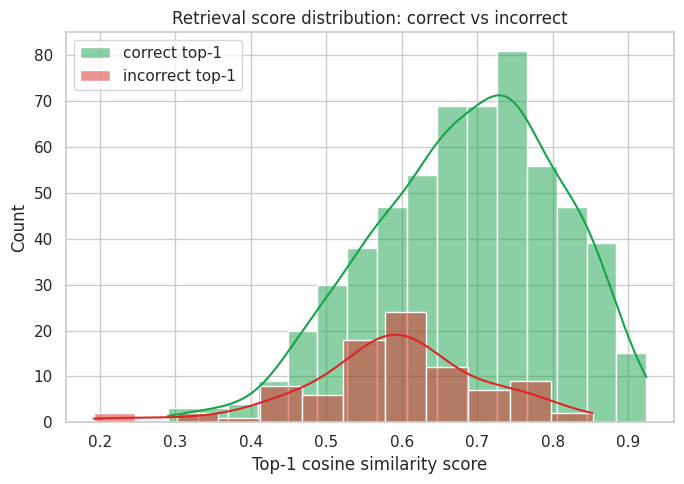

In [9]:
# Top-1 match score distribution — correct vs incorrect retrievals.
# A clean separation here would justify a confidence threshold for
# escalation/fallback in the backend (similar to CONFIDENCE_THRESHOLD logic).
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(eval_results[eval_results["hit@1"]]["top1_score"], color="#16a34a", label="correct top-1", kde=True, alpha=0.5, ax=ax)
sns.histplot(eval_results[~eval_results["hit@1"]]["top1_score"], color="#dc2626", label="incorrect top-1", kde=True, alpha=0.5, ax=ax)
ax.set_xlabel("Top-1 cosine similarity score")
ax.set_title("Retrieval score distribution: correct vs incorrect")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/retrieval_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

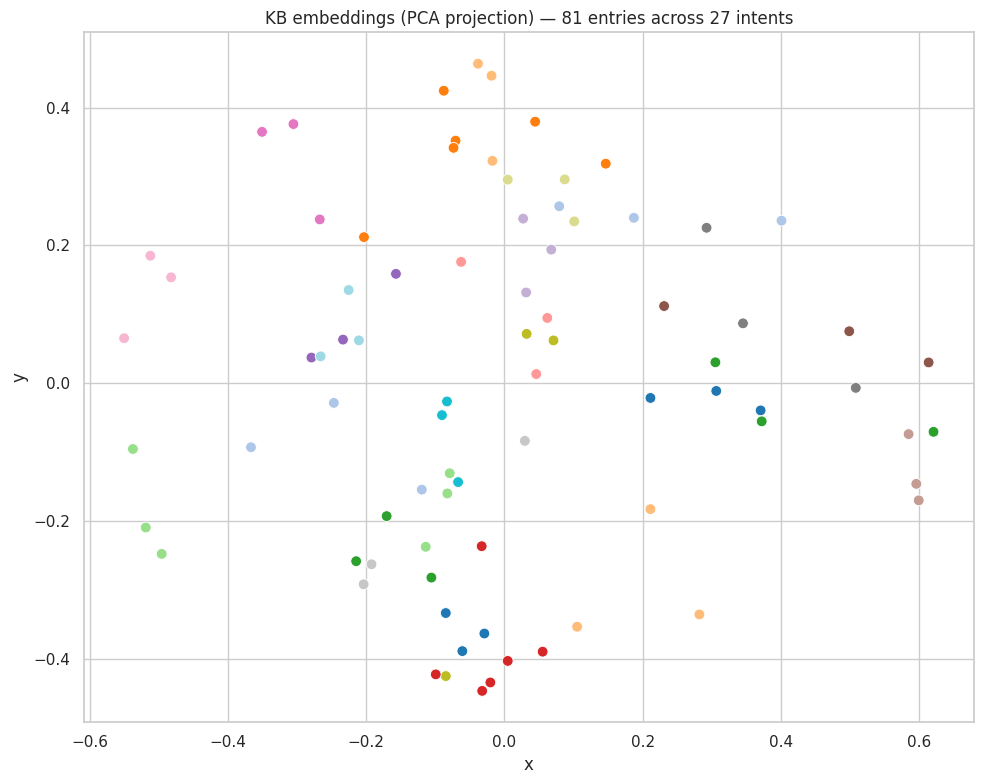

In [10]:
# 2D projection of KB embeddings — visualizes how separable intents are in
# embedding space; tight, well-separated clusters explain good hit-rates,
# overlapping clusters explain the confused intents above.
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=42).fit_transform(embeddings)
plot_df = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "intent": kb_intents})

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=plot_df, x="x", y="y", hue="intent", palette="tab20", s=60, ax=ax, legend=False)
ax.set_title(f"KB embeddings (PCA projection) — {len(kb)} entries across {len(set(kb_intents))} intents")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/kb_embedding_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
eval_results.to_csv(f"{FIG_DIR}/retrieval_eval_results.csv", index=False)
print("Saved retrieval_eval_results.csv and all figures to", FIG_DIR)

Saved retrieval_eval_results.csv and all figures to /kaggle/working/figures


## NER sanity check (spaCy + regex for structured entities)

In [12]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")
ORDER_ID_RE = re.compile(r"\b(?:order\s*#?\s*)?([A-Z]{0,3}\d{5,10})\b", re.IGNORECASE)
ERROR_CODE_RE = re.compile(r"\b(E\d{3}|0x[0-9A-Fa-f]{2,4})\b")

def extract_entities(text):
    order_ids = [m.group(1) for m in ORDER_ID_RE.finditer(text)]
    error_codes = ERROR_CODE_RE.findall(text)
    doc = nlp(text)
    spacy_entities = [{"text": ent.text, "label": ent.label_} for ent in doc.ents]
    return {"order_ids": order_ids, "error_codes": error_codes, "spacy_entities": spacy_entities}

extract_entities("I'm getting error code E101 on order 4471829, shipped from Berlin")

{'order_ids': ['4471829'],
 'error_codes': ['E101'],
 'spacy_entities': [{'text': 'E101', 'label': 'PRODUCT'},
  {'text': '4471829', 'label': 'DATE'},
  {'text': 'Berlin', 'label': 'GPE'}]}

## NER batch run + entity-type distribution

Runs extraction over a sample of held-out queries (the same `eval_df` used
for retrieval) and charts how often each entity type fires — there's no
ground-truth NER labels in this dataset, so this is a coverage/sanity chart
rather than a precision/recall metric: it shows what the regex+spaCy
pipeline actually picks up on real customer-support phrasing.

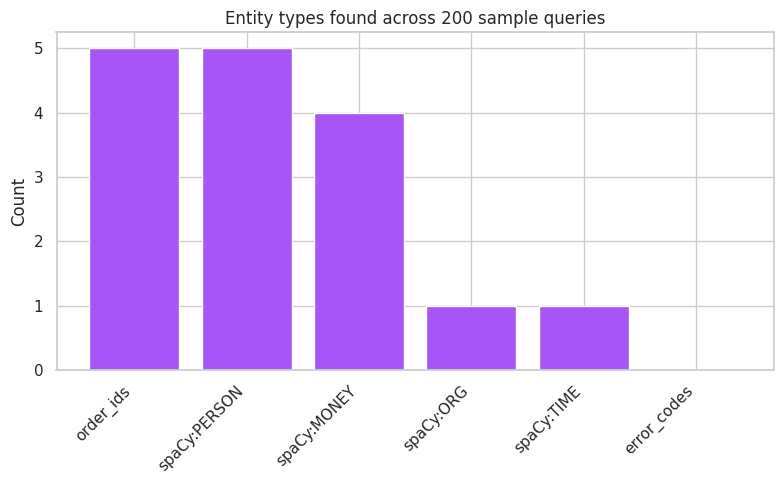

{'order_ids': 5,
 'spaCy:PERSON': 5,
 'spaCy:MONEY': 4,
 'spaCy:ORG': 1,
 'spaCy:TIME': 1,
 'error_codes': 0}

In [13]:
sample_queries = eval_df["text"].sample(min(200, len(eval_df)), random_state=42).tolist()

entity_type_counts = {"order_ids": 0, "error_codes": 0}
spacy_label_counts = {}
for text in sample_queries:
    ents = extract_entities(text)
    entity_type_counts["order_ids"] += len(ents["order_ids"])
    entity_type_counts["error_codes"] += len(ents["error_codes"])
    for e in ents["spacy_entities"]:
        spacy_label_counts[e["label"]] = spacy_label_counts.get(e["label"], 0) + 1

combined_counts = {**entity_type_counts, **{f"spaCy:{k}": v for k, v in spacy_label_counts.items()}}
combined_counts = dict(sorted(combined_counts.items(), key=lambda kv: kv[1], reverse=True))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(combined_counts.keys(), combined_counts.values(), color="#a855f7")
ax.set_ylabel("Count")
ax.set_title(f"Entity types found across {len(sample_queries)} sample queries")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ner_entity_counts.png", dpi=150, bbox_inches="tight")
plt.show()
combined_counts

## Push retrieval/NER outputs to the same Hugging Face Hub repo

Adds this notebook's artifacts (FAISS index, embeddings, evaluation
figures/CSVs) to the same `HF_REPO_ID` repo notebook 01 created — one repo
ends up holding everything needed to run the backend without re-running
either notebook.

In [14]:
if not hf_token:
    print("No HF_TOKEN found — skipping upload. Add it via Add-ons -> Secrets to enable this cell.")
else:
    from huggingface_hub import HfApi, create_repo

    api = HfApi(token=hf_token)
    create_repo(HF_REPO_ID, repo_type="model", token=hf_token, exist_ok=True)

    api.upload_folder(
        folder_path="/kaggle/working",
        repo_id=HF_REPO_ID,
        repo_type="model",
        token=hf_token,
        allow_patterns=["kb_embeddings.npy", "kb_index.faiss", "figures/*"],
        commit_message="Upload retrieval index/embeddings and evaluation figures from notebook 02",
    )
    print(f"Uploaded to https://huggingface.co/{HF_REPO_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded to https://huggingface.co/unixio/neuralnav-intent-models
